In [1]:
import pandas as pd
pd.set_option('display.max_rows', 50)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', 30)

import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from termcolor import colored

from utils import *
from utils_json import update_json
from data import datasetup

In [2]:
kwargs = {'data_path': 'data'
          , 'with_update' : False
          , 'in_place' : False
          , 'save_to_sql': False
    }

df = load_data(**kwargs)

df.shape

(1737, 9)

In [3]:
describe_analysis(df, datetime(2024,1,1), 'it_IT', True) # datetime.now() 

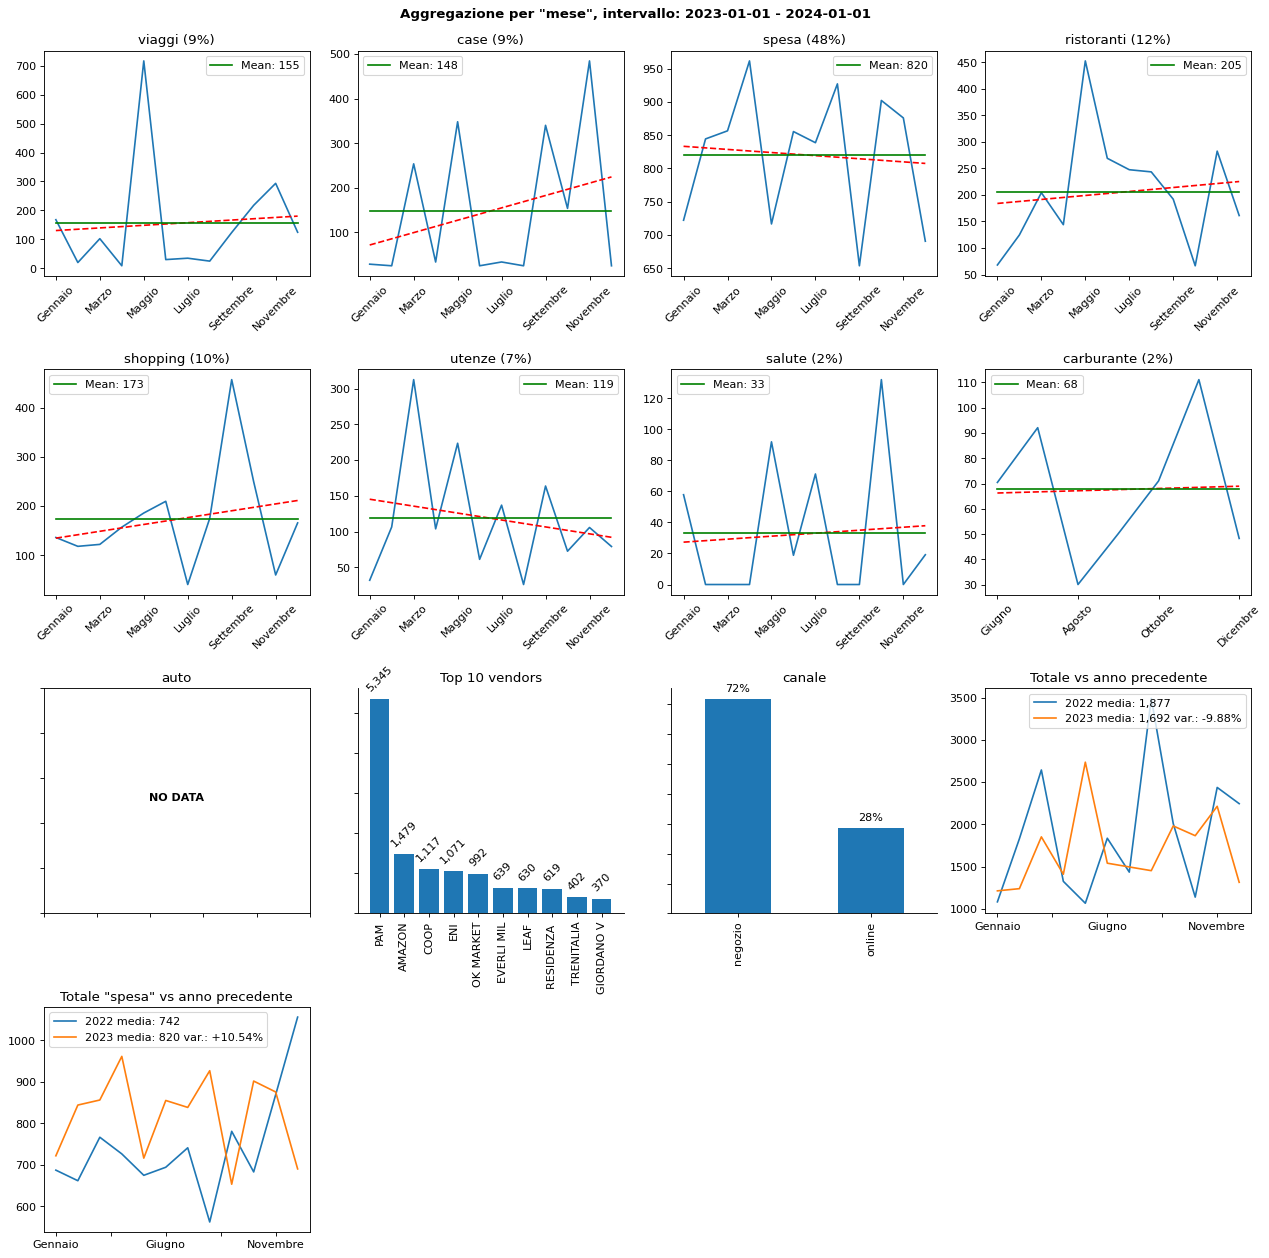

In [5]:
kw = {
    'df': df
    , 'start_date': '2023-01-01'
    , 'end_date': '2024-01-01'
    , '_sampling': ('M', 'mese')
    , '_nlargest': 10
    , '_classification': None # 'ristoranti'
    , '_locale': 'it_IT'
    , '_fig': {'figsize': (16,16), 'dpi':80}
}

plot_dashboard(**kw)

In [ ]:
# Self made statistics

kwargs_skew = {'cat': ['classificazione']
           , 'num': ['importo']
           , 'filter_base': (df.data_acquisto >= '2023-01-01') & (df.data_acquisto <= '2023-9-30')
           , 'filter_eval': df.data_acquisto >= '2023-10-01'}

kwargs_slice = {'slice_col': 'classificazione', 'slice_index': 0}

data_validation(
    df = df # NO resampling
    , _include = ['object', 'number']
    , _exclude = None # 'object'
    , _skew = kwargs_skew
    , _slice = None # kwargs_slice
    , _schema = False
)

In [ ]:
# checking value of a classification by date range

print(
    '{:,.2f}€'.format(
    df.query('data_acquisto >= "2023-01-01" and data_acquisto <= "2023-11-30"')
    .loc[df.classificazione == 'spesa']
                                .set_index('data_acquisto')
                                ['importo'].sum()))